In [17]:

import matplotlib.pyplot as plt
import math
import numpy as np

N = 100
u_L = [0.5] * N
u_R = [1.76] * N

# Радиусы колес 
W_R = 1
W_L = 1

# Колесная база робота
B = 2

T = 0.2

def s_L(k):
    return W_L * u_L[k]

def s_R(k):
    return W_R * u_R[k] 

def s_t(k):
    return (s_R(k) + s_L(k)) / 2

def s_r(k):
    return (s_R(k) - s_L(k)) / (2 * B)

length_u_L = len(u_L)

x_true = [0.0]
y_true = [0.0]
r_true = [0.0]


for k in range(N):
    x_true.append(x_true[k] + T * s_t(k) * math.cos(r_true[k]) -
                  (T**2 / 2) * s_t(k) * s_r(k) * math.sin(r_true[k]))
    y_true.append(y_true[k] + T * s_t(k) * math.sin(r_true[k]) +
                  (T**2 / 2) * s_t(k) * s_r(k) * math.cos(r_true[k]))
    r_true.append(r_true[k] + T * s_r(k))


x_obsession = np.array(x_true) + np.random.normal(0, 0.05, length_u_L + 1)
y_obsession = np.array(y_true) + np.random.normal(0, 0.05, length_u_L + 1)
r_obsession = np.array(r_true) + np.random.normal(0, 0.05, length_u_L + 1)

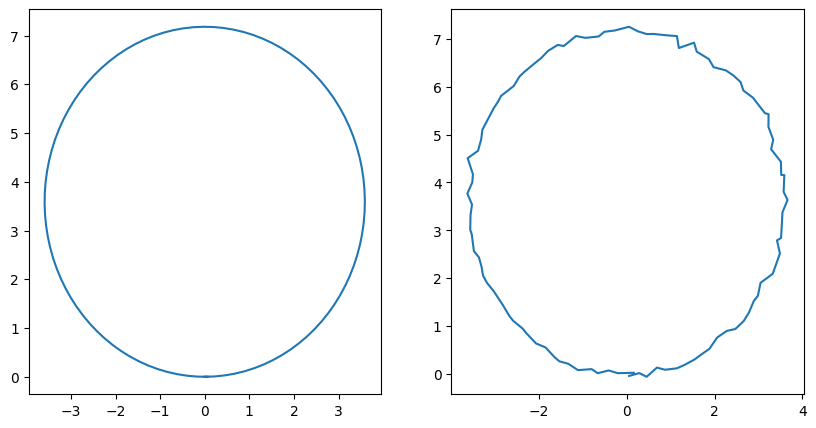

In [18]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(x_true,y_true)
plt.subplot(1, 2, 2)
plt.plot(x_obsession,y_obsession)
plt.show()

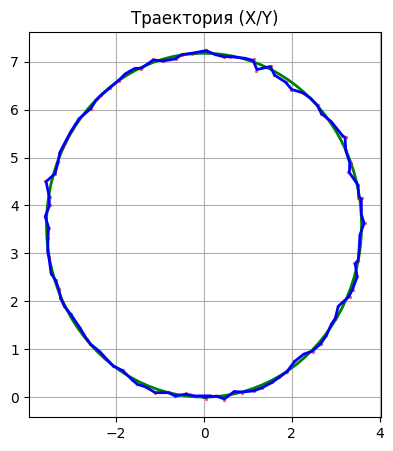

In [20]:

X_est = np.array([[0.0],
                [0.0],
                [0.0]])
X_history = [np.copy(X_est)]

# Ковариация ошибки (P)
# начальная неопределённость в оценке состояния [x, y, θ].
P = np.eye(3) *  0.5
# Шум процесса (Q)
# неопределённость в модели движения робота
Q = np.eye(3) * 0.01
# Шум измерения (R)
# точность сенсоров, измеряющих [x, y, θ]
R = np.eye(3) * 0.05**2

def get_Jacobian(k, state):
    """Вычисление матрицы Якобиана F"""
    df1dr = -T * s_t(k) * math.sin(state[2, 0]) - (T**2 / 2) * s_t(k) * s_r(k) * math.cos(state[2, 0])
    df2dr =  T * s_t(k) * math.cos(state[2, 0]) - (T**2 / 2) * s_t(k) * s_r(k) * math.sin(state[2, 0])
    
    return np.array([
        [1, 0, df1dr],
        [0, 1, df2dr],
        [0, 0, 1]
    ])

def predict(state, k):
    """Функция прогноза f"""
    x, y, r = state[0, 0], state[1, 0], state[2, 0]
    x_p = x + T * s_t(k) * math.cos(r) - (T**2 / 2) * s_t(k) * s_r(k) * math.sin(r)
    y_p = y + T * s_t(k) * math.sin(r) + (T**2 / 2) * s_t(k) * s_r(k) * math.cos(r)
    r_p = r + T * s_r(k)
    return np.array([[x_p], [y_p], [r_p]])

# Запуск фильтра
for k in range(length_u_L):
    # 1. Прогноз 
    X_pred = predict(X_est, k)
    F = get_Jacobian(k, X_est)
    P_pred = F @ P @ F.T + Q 

    # 2. Измерение
    Z_k = np.array([[x_obsession[k+1]], [y_obsession[k+1]], [r_obsession[k+1]]])
    H = np.eye(3)

    # 3. Коррекция
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S) 
    
    X_est = X_pred + K @ (Z_k - X_pred)
    P = (np.eye(3) - K @ H) @ P_pred
    X_history.append(X_est.copy())

X_history = np.array(X_history).reshape(-1, 3)

plt.figure(figsize=(10, 5))

# График траектории (X vs Y)
plt.subplot(1, 2, 1)
plt.plot(x_true, y_true, 'g-', label='Истинная', linewidth=2)
plt.plot(x_obsession, y_obsession, 'r.', label='Измерения (Шум)', markersize=3, alpha=0.5)
plt.plot(X_history[:, 0], X_history[:, 1], 'b-', label='EKF Оценка', linewidth=2)
plt.title('Траектория (X/Y)')
plt.grid(True)

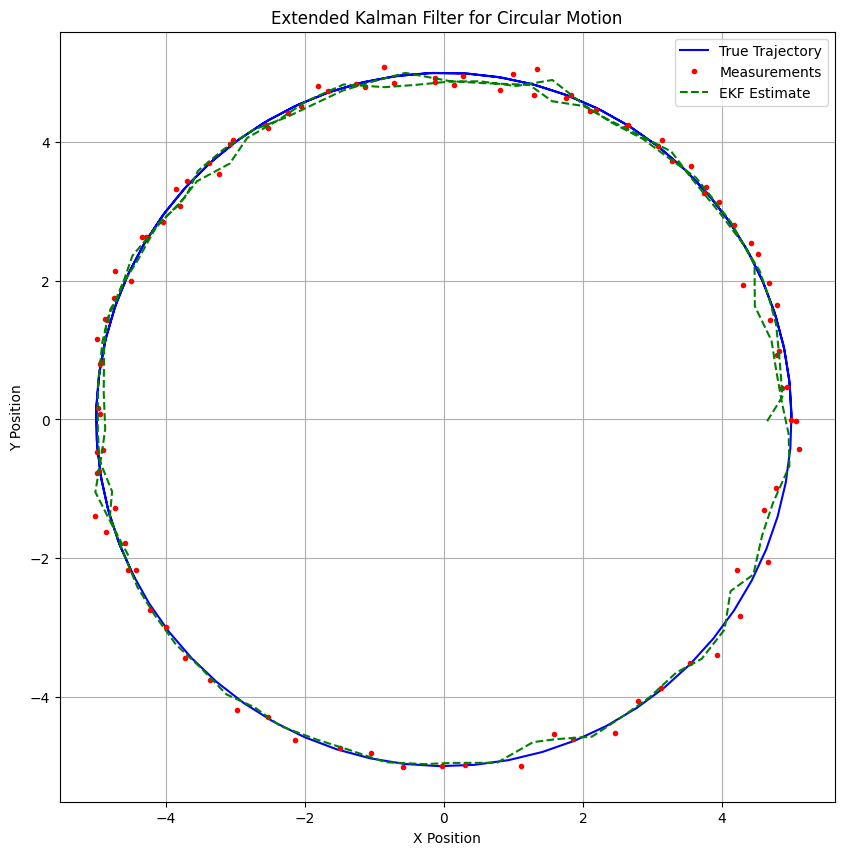

MSE of raw measurements: 0.0102
MSE of EKF estimates: 0.0422


In [25]:
import numpy as np
import matplotlib.pyplot as plt

class ExtendedKalmanFilter:
    def __init__(self, f, h, Q, R, P, x0):
        self.f = f  # нелинейная функция перехода состояния
        self.h = h  # нелинейная функция измерения
        self.Q = Q  # ковариация шума процесса
        self.R = R  # ковариация шума измерения
        self.P = P  # начальная ковариация ошибки
        self.x = x0 # начальное состояние

    def predict(self, u=0):
        self.x = self.f(self.x, u)
        F = self.jacobian_f(self.x, u)
        self.P = np.dot(np.dot(F, self.P), F.T) + self.Q
        return self.x

    def update(self, z):
        H = self.jacobian_h(self.x)
        y = z - self.h(self.x)
        S = np.dot(np.dot(H, self.P), H.T) + self.R
        K = np.dot(np.dot(self.P, H.T), np.linalg.inv(S))
        self.x = self.x + np.dot(K, y)
        I = np.eye(len(self.x))
        self.P = np.dot((I - np.dot(K, H)), self.P)
        return self.x

    def jacobian_f(self, x, u):
        # Вычисление якобиана функции f
        return np.array([[1, 0, -u*np.sin(x[2]), u*np.cos(x[2])],
                         [0, 1, u*np.cos(x[2]), u*np.sin(x[2])],
                         [0, 0, 1, 0],
                         [0, 0, 0, 1]])

    def jacobian_h(self, x):
        # Вычисление якобиана функции h
        return np.array([[1, 0, 0, 0],
                         [0, 1, 0, 0]])

# Определение нелинейных функций модели
def f(x, u):
    # x = [x, y, theta, v]
    return np.array([x[0] + u*np.cos(x[2]),
                     x[1] + u*np.sin(x[2]),
                     x[2] + u/0.1,
                     x[3]])

def h(x):
    return np.array([x[0], x[1]])

# Параметры модели
Q = np.eye(4) * 0.1
R = np.eye(2) * 0.1
P = np.eye(4)
x0 = np.array([0, 0, 0, 1])

# Создаем EKF
ekf = ExtendedKalmanFilter(f, h, Q, R, P, x0)

# Генерируем данные и применяем фильтр
true_states = []
measurements = []
estimated_states = []

time_steps = 100
dt = 0.1
radius = 5

for t in range(time_steps):
    # Истинное состояние (движение по кругу)
    theta = t * dt
    true_state = np.array([radius * np.cos(theta), 
                           radius * np.sin(theta), 
                           theta + np.pi/2, 
                           radius * dt])
    
    # Генерируем зашумленное измерение
    measurement = h(true_state) + np.random.normal(0, 0.1, 2)
    
    # Применяем EKF
    ekf.predict(u=dt)
    estimated_state = ekf.update(measurement)
    
    true_states.append(true_state[:2])
    measurements.append(measurement)
    estimated_states.append(estimated_state[:2])

# Преобразуем списки в массивы numpy для удобства
true_states = np.array(true_states)
measurements = np.array(measurements)
estimated_states = np.array(estimated_states)

# Визуализация результатов
plt.figure(figsize=(10, 10))
plt.plot(true_states[:, 0], true_states[:, 1], 'b-', label='True Trajectory')
plt.plot(measurements[:, 0], measurements[:, 1], 'r.', label='Measurements')
plt.plot(estimated_states[:, 0], estimated_states[:, 1], 'g--', label='EKF Estimate')
plt.legend()
plt.title('Extended Kalman Filter for Circular Motion')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.axis('equal')
plt.grid(True)
plt.show()

# Анализ ошибки
mse_measurements = np.mean((measurements - true_states[:, :2])**2)
mse_ekf = np.mean((estimated_states - true_states[:, :2])**2)

print(f"MSE of raw measurements: {mse_measurements:.4f}")
print(f"MSE of EKF estimates: {mse_ekf:.4f}")